# AMC
This document processes all the data for the AMC to validate the EWSN paper a bit. 

The core idea is to use transformers and Resnet to look for a good fingerprinting mechanism. 

A good fingerprinting mechanism has a
1. High recall (It should be able to corre) 99%
2. Low false positive rate (This is all extra cost) 
3. Is very small.


/tmp/ipykernel_2692978/3319906012.py:105: RuntimeWarning: invalid value encountered in divide
  f1 = np.nan_to_num(2*precision*recall/(precision+recall))


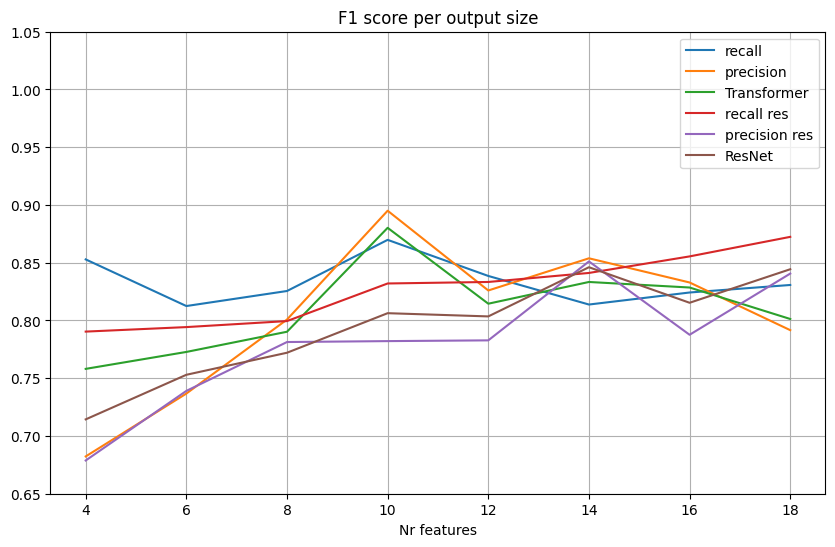

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json 
from dataclasses import dataclass

class Model_sizes:
    def __init__(self,m_name='ResNet'):
        self.name =m_name
        self.sizes = [4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40]
        self.sizes = [4,6,8,10,12,14,16,18]
        self.models = [Models(m_name, s) for s in self.sizes]
        self.metrics = np.nan_to_num([m.metrics for m in self.models])


class Models:
    def __init__(self, m_name='ResNet', out_size=4):
        self.out_size=out_size
        self.name=m_name
        self.models = [Model(m_name=m_name,out_size=out_size,id=i)for i in range(4)]
        self.metrics = np.array([m.test_metrics for m in self.models])
        self.best_f1 = np.argmax(np.nan_to_num([m.train_metrics[2] for m in self.models]))
    
                

class Model:
    def __init__(self, m_name='ResNet', out_size=4,id=0):
        self.out_size=out_size
        self.name=m_name
        self.fn = f'../Results/AMC/{m_name}_{out_size}/res_{id}/'
        self.train = DataTrain(**np.load(self.fn+'Results/train.npy',allow_pickle=True).item())
        self.val = Data(**np.load(self.fn+'Results/val.npy',allow_pickle=True).item())
        self.test = Data(**np.load(self.fn+'Results/test.npy',allow_pickle=True).item())
        self.calc()
    
    def calc(self):    
        self.th = self.train.th
        self.train_metrics = self.train.cal_metrics(self.th) #recall, precision, f1, accuracy
        self.val_metrics = self.val.cal_metrics(self.th) #recall, precision, f1, accuracy
        self.test_metrics = self.test.cal_metrics(self.th) #recall, precision, f1, accuracy
    
    def quantize(self,nr_bits):
        quantizer = self.train.re_init_quant(nr_bits)
        self.val.set_quant(quantizer)
        self.test.set_quant(quantizer)
        self.calc()


@dataclass
class Data:
    A: np.ndarray
    T: np.ndarray
    Loss: np.ndarray
    mod_i: np.ndarray
    flag: np.ndarray
    mod_j : np.ndarray

    def __post_init__(self):
        self.quantizer = Quantizer(np.concatenate([self.A,self.T]),n_bits=32)

    def set_quant(self, quant):
        self.quantizer = quant

    @property
    def match(self): return self.flag==1

    @property
    def distance(self): return np.linalg.norm(self.quantizer.sim(self.A) - self.quantizer.sim(self.T), axis=1)


    def cal_metrics(self, th):
        predict = self.distance<th
        TP= np.sum(self.match&predict)
        TN= np.sum(~self.match&~predict)
        FP = np.sum(~self.match&predict)
        FN = np.sum(self.match&~predict)

        recall = TP/(TP+FN)
        precision = TP/(TP+FP)
        f1 =np.nan_to_num(2*precision*recall/(precision+recall))
        accuracy = (TP+TN)/(TP+TN+FN+FP)
        return recall, precision, f1, accuracy

class DataTrain(Data):

    def re_init_quant(self,n_bits=32):
        self.quantizer = Quantizer(np.concatenate([self.A,self.T]),n_bits=n_bits)
        return self.quantizer

    @property
    def th(self):
        # step 1: Sort on loss
        idx_s = np.argsort(self.distance)
        right = self.match[idx_s]
        distances = self.distance[idx_s]
        
        # step 2: devide in 4 groups: 
        TP = np.cumsum(right)               # Matching and accepted
        FP = np.cumsum(~right)              # Different but accepted
        # TN = np.cumsum(~right[::-1])[::-1]  # Different and rejected
        FN = np.cumsum(right[::-1])[::-1]   # Matching but rejected
        
        # step 3: calculate all metrics
        recall = TP/(TP+FN)
        precision = TP/(TP+FP)
        f1 = np.nan_to_num(2*precision*recall/(precision+recall))

        # return distances for which f1 is max
        return distances[np.argmax(f1)]

    def plot_his(self, title="Histogram of distances"):
        plt.figure(figsize=(15, 4))
        counts, bins = np.histogram(self.distance[self.match],bins=np.arange(0,np.max(self.distance),0.0001))
        plt.stairs(counts, bins,color='green',label='correct class')
        counts, bins = np.histogram(self.distance[~(self.match)],bins=np.arange(0,np.max(self.distance),0.0001))
        plt.stairs(counts, bins,color='red',label='incorrect class')
        plt.title(title)
        plt.legend()
        plt.show()

    # get recall, precision and f1 in function of threshold!
    def plot_metrics(self):
        # step 1: Sort on loss
        idx_s = np.argsort(self.distance)
        right = self.match[idx_s]
        loss = self.distance[idx_s]
        
        # step 2: devide in 4 groups: 
        TP = np.cumsum(right)               # Matching and accepted
        FP = np.cumsum(~right)              # Different but accepted
        TN = np.cumsum(~right[::-1])[::-1]  # Different and rejected
        FN = np.cumsum(right[::-1])[::-1]   # Matching but rejected
        
        # step 3: calculate all metrics
        recall = TP/(TP+FN)
        precision = TP/(TP+FP)
        f1 = 2*precision*recall/(precision+recall)
        accuracy = (TP+TN)/(TP+TN+FN+FP)

        # step 4: plot
        plt.figure(figsize=(10,6))
        plt.plot(loss,precision,label='precision')
        plt.plot(loss,recall,label='recall')
        plt.plot(loss,f1,label='f1')
        plt.plot(loss,accuracy,label='accuracy')
        plt.grid(True)
        plt.legend()
        plt.show()


class Quantizer:
    """ This quantizer is build around the train data and applied to the test_data"""
    def __init__(self,features:np.ndarray, n_bits=32):
        self.k = 2 ** n_bits
        f_min = np.min(features, axis=0, keepdims=True)
        f_max = np.max(features, axis=0, keepdims=True)
    
        scale = (f_max - f_min) / (self.k - 1)
        scale[scale == 0] = 1e-16  # Prevent division by zero

        self.f_min=f_min
        self.scale = scale

    def quantize(self,seq):
        return np.round((seq - self.f_min) / self.scale)  # or smaller dtype depending on bits
    
    def dequantize(self,seq):
        return self.f_min + seq * self.scale   
    
    def sim(self,seq):
        return self.f_min + np.round((seq - self.f_min) / self.scale)* self.scale  



t = Model_sizes(m_name='Transformer')    
plt.figure(figsize=(10,6))
plt.plot(t.sizes,np.max(t.metrics, axis=1)[:,0],label='recall')
plt.plot(t.sizes,np.max(t.metrics, axis=1)[:,1],label='precision')
plt.plot(t.sizes,np.max(t.metrics, axis=1)[:,2],label='Transformer')
# plt.plot(t.sizes,np.max(t.metrics, axis=1)[:,3],label='accuracy')

t = Model_sizes(m_name='ResNet')    
plt.plot(t.sizes,np.max(t.metrics, axis=1)[:,0],label='recall res')
plt.plot(t.sizes,np.max(t.metrics, axis=1)[:,1],label='precision res')
plt.plot(t.sizes,np.max(t.metrics, axis=1)[:,2],label='ResNet')
# plt.plot(t.sizes,np.max(t.metrics, axis=1)[:,3],label='accuracy res')
plt.grid(True)
plt.legend()
plt.title('F1 score per output size')
plt.xlabel('Nr features')
plt.ylim(0.65,1.05)
plt.show()






In [2]:
best_models = {}
for name in ['Transformer', 'ResNet']:
    t = Model_sizes(m_name=name)
    best_models[name] = [(m.out_size,m.best_f1) for m in t.models ]
        
print(best_models)

/tmp/ipykernel_2692978/3319906012.py:105: RuntimeWarning: invalid value encountered in divide
  f1 = np.nan_to_num(2*precision*recall/(precision+recall))


{'Transformer': [(4, 0), (6, 0), (8, 1), (10, 0), (12, 1), (14, 2), (16, 3), (18, 0)], 'ResNet': [(4, 3), (6, 3), (8, 1), (10, 1), (12, 0), (14, 3), (16, 2), (18, 0)]}


/tmp/ipykernel_2692978/3319906012.py:105: RuntimeWarning: invalid value encountered in divide
  f1 = np.nan_to_num(2*precision*recall/(precision+recall))


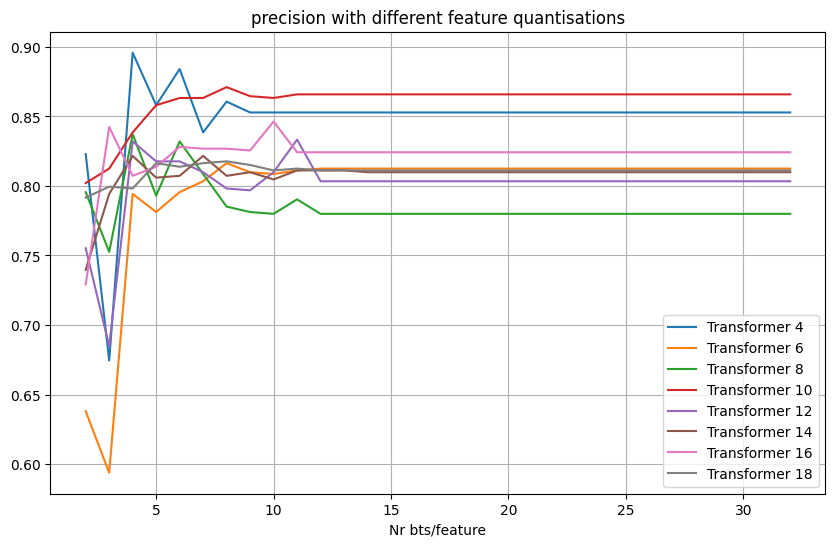

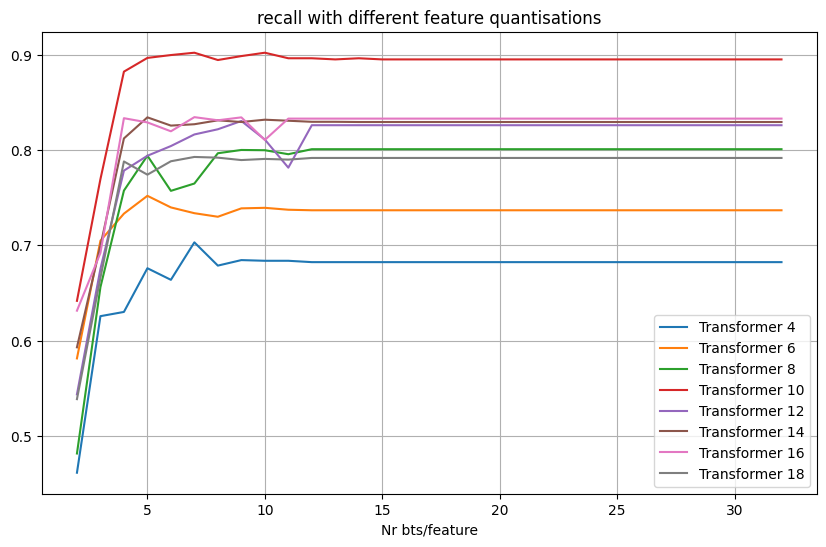

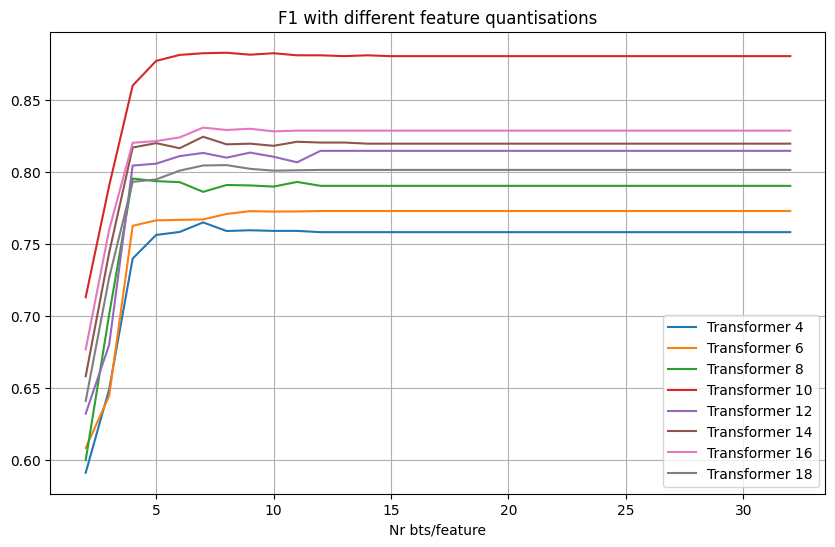

In [4]:
plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q) # x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,0],label=f'Transformer {out_size}')

plt.grid(True)
plt.legend()
plt.title('precision with different feature quantisations')
plt.xlabel('Nr bts/feature')
# plt.ylim(0.9,1)
plt.show()
plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q) # x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,1],label=f'Transformer {out_size}')

plt.grid(True)
plt.legend()
plt.title('recall with different feature quantisations')
plt.xlabel('Nr bts/feature')
# plt.ylim(0.9,1)
plt.show()

plt.figure(figsize=(10,6))
for out_size, id in best_models['Transformer']:
    m = Model(m_name='Transformer',out_size=out_size,id=id)
    metrics = []
    x = []
    quantization = range(2,33)
    for q in quantization:
        m.quantize(q)
        metrics.append(m.test_metrics)
        x.append(q) # x.append(q*out_size)

    metrics=np.array(metrics)
    plt.plot(x,metrics[:,2],label=f'Transformer {out_size}')

plt.grid(True)
plt.legend()
plt.title('F1 with different feature quantisations')
plt.xlabel('Nr bts/feature')
# plt.ylim(0.9,1)
plt.show()

